# Spike-data sanity checks (streamed, one session)

Lazily stream a single session of DANDI dandiset
[000447](https://dandiarchive.org/dandiset/000447) straight from S3 (no local
download) and run basic quality-control visualizations before committing to the
extraction pipeline.

Checks:
1. Session / epoch / unit-count overview (CA1 vs PFC kept separate)
2. Spike raster across the whole session, split by region, with epoch bounds
3. Mean firing rate per unit, by region
4. Inter-spike-interval histogram + refractory-period violation rate (sort quality)
5. Population firing rate over time
6. Behavior: trajectory and speed, to confirm position data is sane


## Setup
Add `src/` to the path and pull in the streaming helper from stage 0.

In [1]:
import sys
import pathlib

# locate repo root (works whether cwd is repo root or notebooks/)
for _p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_p / "src" / "00_download.py").exists():
        sys.path.insert(0, str(_p / "src"))
        break

from importlib import import_module
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dl = import_module("00_download")   # module name starts with a digit
from config import REGIONS

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 100

## Pick a session
List the NWB assets and choose one to stream.

In [2]:
asset_paths = [p for p in dl.list_asset_paths() if p.endswith(".nwb")]
for i, p in enumerate(asset_paths):
    print(i, p)

SESSION = asset_paths[0]   # change the index to inspect a different subject
SESSION

A newer version (0.76.7) of dandi/dandi-cli is available. You are using 0.75.1


0 sub-JDS-NFN-AM2/sub-JDS-NFN-AM2_behavior+ecephys.nwb
1 sub-JDS-NFN-JS34/sub-JDS-NFN-JS34_behavior+ecephys.nwb
2 sub-JDS-NFN-JS17/sub-JDS-NFN-JS17_behavior+ecephys.nwb
3 sub-JDS-NFN-JS21/sub-JDS-NFN-JS21_behavior+ecephys.nwb
4 sub-JDS-NFN-ZT2/sub-JDS-NFN-ZT2_behavior+ecephys.nwb


'sub-JDS-NFN-AM2/sub-JDS-NFN-AM2_behavior+ecephys.nwb'

## Lazily load just what we need

`stream_nwb` opens the remote file with remfile/h5py so only the bytes we index
are fetched. All NWB reads happen inside the `with` block; we copy the small
arrays we need into memory so the plots below work after the file is closed.

In [3]:
with dl.stream_nwb(SESSION) as nwb:
    session_desc = nwb.session_description
    subject_id = getattr(nwb.subject, "subject_id", None)

    # epoch intervals -> (start, stop) per behavioral epoch
    epochs = nwb.intervals["epoch intervals"].to_dataframe()[["start_time", "stop_time"]]
    epochs = epochs.reset_index(drop=True)

    # per-unit region via the linked electrodes table (location = CA1 / PFC)
    n_units = len(nwb.units)
    unit_region = np.empty(n_units, dtype=object)
    for i in range(n_units):
        locs = nwb.units["electrodes"][i]["location"].unique().tolist()
        unit_region[i] = locs[0] if len(locs) == 1 else "mixed"

    # spike times per unit (lists of 1-D arrays, read eagerly here)
    spike_times = [np.asarray(nwb.units["spike_times"][i]) for i in range(n_units)]

    # behavior: x, y (cm) and speed (cm/s) with timestamps
    ss = nwb.processing["behavior"].data_interfaces["Position"].spatial_series["SpatialSeries"]
    pos_t = np.asarray(ss.timestamps[:])
    pos_data = np.asarray(ss.data[:])
    pos_xy = pos_data[:, :2]
    speed = pos_data[:, 2]

print(f"subject         : {subject_id}")
print(f"description     : {session_desc}")
print(f"n_units         : {n_units}")
for r in REGIONS:
    print(f"  {r:4s} units    : {(unit_region == r).sum()}")
print(f"n_epochs        : {len(epochs)}")
print(f"recording span  : {epochs['start_time'].min():.1f}–{epochs['stop_time'].max():.1f} s")
epochs

subject         : JDS-NFN-AM2
description     : Novel familiar novel experiment
n_units         : 57
  CA1  units    : 32
  PFC  units    : 25
n_epochs        : 3
recording span  : 2322.5–11691.4 s


,start_time,stop_time
0,2322.502000,3200.927333
1,6273.739067,7172.817867
2,10745.758000,11691.354500


## 1. Spike raster over the whole session

Units grouped by region (CA1 then PFC); dashed lines mark epoch boundaries.
The first epoch is the novel-W-track exposure; later epochs are familiar
(see CLAUDE.md).

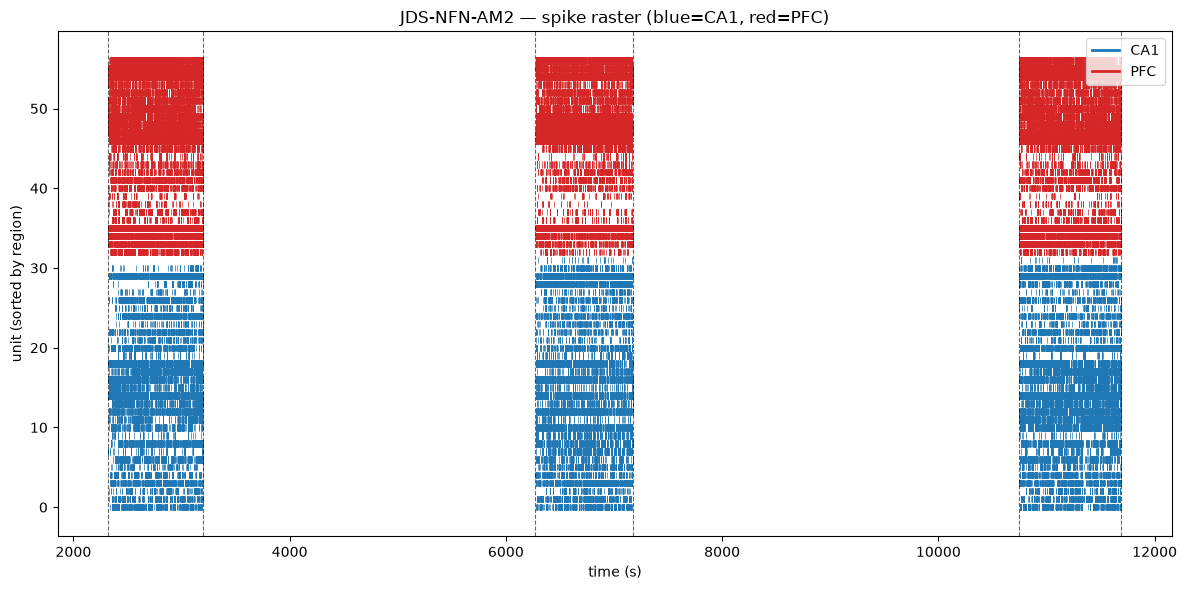

In [4]:
order = np.argsort(unit_region, kind="stable")   # group CA1 then PFC
region_color = {"CA1": "tab:blue", "PFC": "tab:red"}
colors = [region_color.get(unit_region[i], "gray") for i in order]

fig, ax = plt.subplots(figsize=(12, 6))
ax.eventplot([spike_times[i] for i in order], colors=colors,
             linewidths=0.5, linelengths=0.8)
for _, ep in epochs.iterrows():
    ax.axvline(ep["start_time"], color="k", ls="--", lw=0.8, alpha=0.6)
    ax.axvline(ep["stop_time"], color="k", ls="--", lw=0.8, alpha=0.6)
ax.set_xlabel("time (s)")
ax.set_ylabel("unit (sorted by region)")
ax.set_title(f"{subject_id} — spike raster (blue=CA1, red=PFC)")
handles = [plt.Line2D([0], [0], color=c, lw=2) for c in region_color.values()]
ax.legend(handles, region_color.keys(), loc="upper right")
plt.tight_layout()

## 2. Mean firing rate per unit, by region
Computed over the full recording span.

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
CA1,32.0,0.417774,0.350989,0.008325,0.177770,0.355753,0.533923,1.407963
PFC,25.0,0.841828,0.789287,0.043442,0.271431,0.600180,1.251808,2.796180


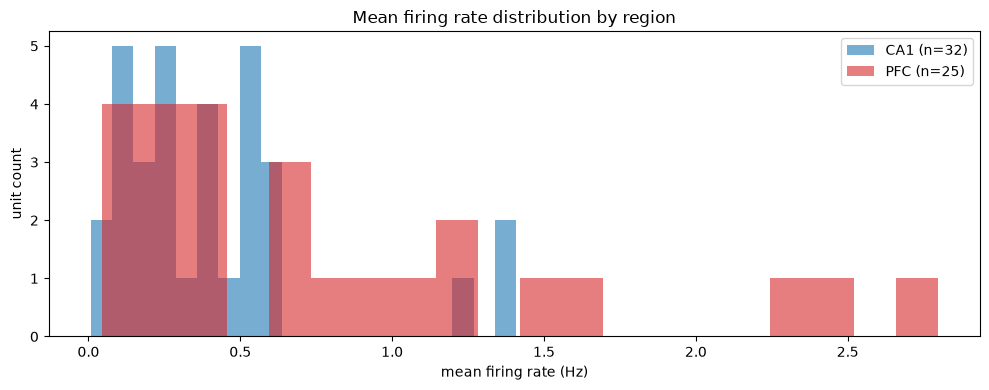

In [5]:
span = epochs["stop_time"].max() - epochs["start_time"].min()
mean_rate = np.array([len(st) / span for st in spike_times])

fig, ax = plt.subplots()
for r in REGIONS:
    m = unit_region == r
    ax.hist(mean_rate[m], bins=20, alpha=0.6, label=f"{r} (n={m.sum()})",
            color=region_color.get(r))
ax.set_xlabel("mean firing rate (Hz)")
ax.set_ylabel("unit count")
ax.set_title("Mean firing rate distribution by region")
ax.legend()
plt.tight_layout()

pd.DataFrame({"region": unit_region, "mean_rate_hz": mean_rate}).groupby("region")["mean_rate_hz"].describe()

## 3. ISI histogram + refractory-period check

For an example unit, the inter-spike-interval distribution should show few
intervals below the ~2 ms refractory period. A high violation fraction flags
merged/contaminated clusters.

median refractory-violation fraction: 0.013%


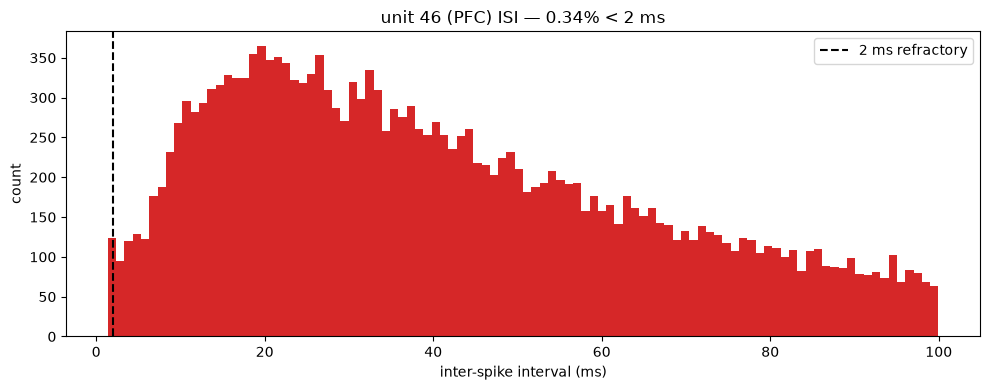

In [6]:
EXAMPLE_UNIT = int(np.argmax(mean_rate))   # busiest unit
isi = np.diff(spike_times[EXAMPLE_UNIT]) * 1000.0   # ms
refractory_ms = 2.0
viol = np.mean(isi < refractory_ms)

fig, ax = plt.subplots()
ax.hist(isi[isi < 100], bins=100, color=region_color.get(unit_region[EXAMPLE_UNIT]))
ax.axvline(refractory_ms, color="k", ls="--", label=f"{refractory_ms:g} ms refractory")
ax.set_xlabel("inter-spike interval (ms)")
ax.set_ylabel("count")
ax.set_title(f"unit {EXAMPLE_UNIT} ({unit_region[EXAMPLE_UNIT]}) ISI — "
             f"{viol*100:.2f}% < {refractory_ms:g} ms")
ax.legend()
plt.tight_layout()

# refractory-violation fraction for every unit
viol_frac = np.array([np.mean(np.diff(st) * 1000.0 < refractory_ms) if len(st) > 1 else np.nan
                      for st in spike_times])
print(f"median refractory-violation fraction: {np.nanmedian(viol_frac)*100:.3f}%")

## 4. Population firing rate over time
Spikes from all units, binned; epoch boundaries dashed.

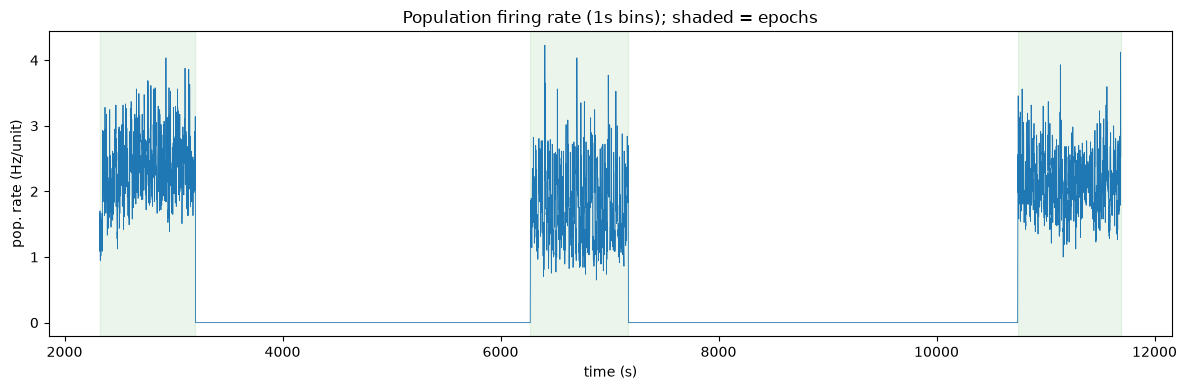

In [7]:
bin_s = 1.0
all_spikes = np.concatenate(spike_times)
t0, t1 = epochs["start_time"].min(), epochs["stop_time"].max()
edges = np.arange(t0, t1 + bin_s, bin_s)
counts, _ = np.histogram(all_spikes, bins=edges)
pop_rate = counts / bin_s / n_units   # mean Hz per unit

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(edges[:-1], pop_rate, lw=0.6)
for _, ep in epochs.iterrows():
    ax.axvspan(ep["start_time"], ep["stop_time"], alpha=0.08, color="green")
ax.set_xlabel("time (s)")
ax.set_ylabel("pop. rate (Hz/unit)")
ax.set_title(f"Population firing rate ({bin_s:g}s bins); shaded = epochs")
plt.tight_layout()

## 5. Behavior sanity check: trajectory and speed

Confirms the position data is well-formed and roughly matches a W-track. Each
epoch's trajectory is plotted separately; speed is shown over time.

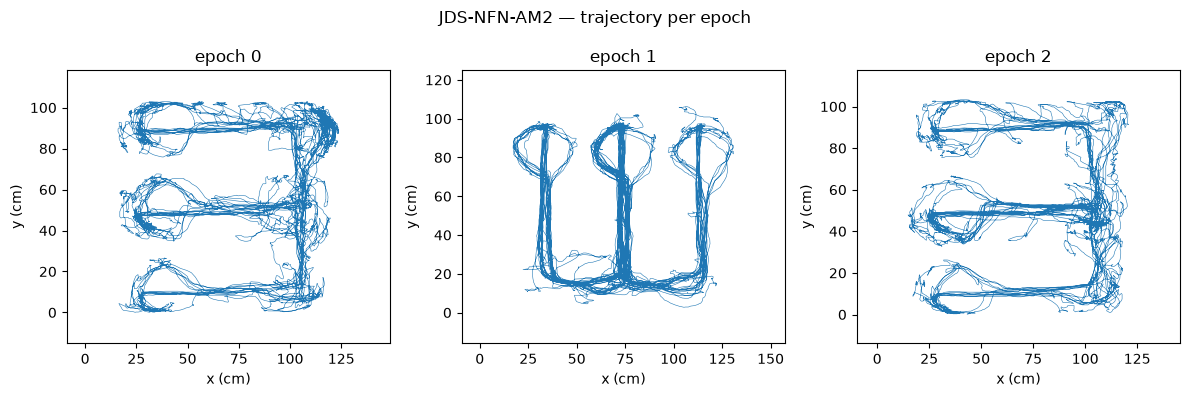

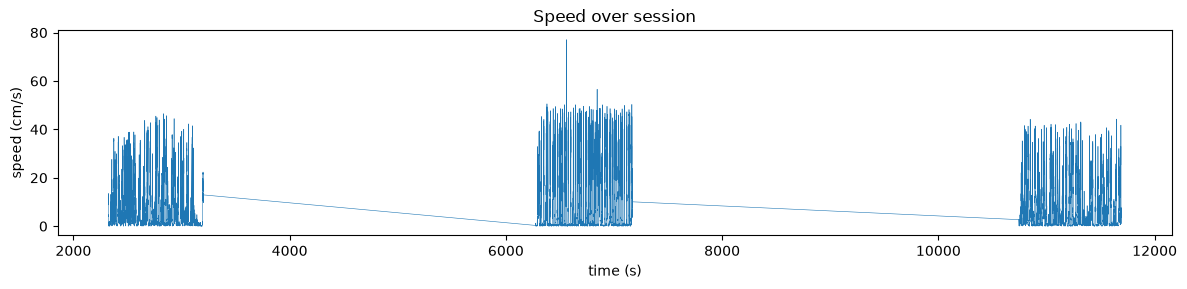

In [8]:
fig, axes = plt.subplots(1, len(epochs), figsize=(4 * len(epochs), 4), squeeze=False)
for k, (_, ep) in enumerate(epochs.iterrows()):
    m = (pos_t >= ep["start_time"]) & (pos_t <= ep["stop_time"])
    ax = axes[0, k]
    ax.plot(pos_xy[m, 0], pos_xy[m, 1], lw=0.4)
    ax.set_title(f"epoch {k}")
    ax.set_xlabel("x (cm)"); ax.set_ylabel("y (cm)")
    ax.set_aspect("equal", adjustable="datalim")
fig.suptitle(f"{subject_id} — trajectory per epoch")
plt.tight_layout()

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(pos_t, speed, lw=0.4)
ax.set_xlabel("time (s)"); ax.set_ylabel("speed (cm/s)")
ax.set_title("Speed over session")
plt.tight_layout()

---
**Next:** these checks confirm the streamed session is well-formed (regions,
epochs, spikes, and behavior all present). Stage 1 (`src/01_extraction.py`) can
now bin these spikes into per-region rate matrices carrying the epoch/condition
and subject metadata columns.